In [25]:
## Import Packages

import pandas as pd
import numpy as np
import seaborn as sns

In [26]:
### Data Load...

data = pd.read_csv('../bitcoin_data/raw/btc_binance_daily.csv')
data.head()

,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.93351
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.10277
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.43256
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.52187
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.21867


In [27]:
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

In [28]:
df = data.copy()

In [29]:
### Check duplicate values
duplicate_rows = df[df.duplicated()]

print("Number of duplicate rows:", duplicate_rows.shape[0])
print(duplicate_rows)

Number of duplicate rows: 0
Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


In [30]:
### Check missing values
missing_values = df.isnull().sum()
print("Number of missing values:", missing_values)

Number of missing values: date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [31]:
### Statistical overview

summary = df.drop(columns=["date"]).describe().round(3)
print(summary)

             open        high         low       close      volume
count    1000.000    1000.000    1000.000    1000.000    1000.000
mean    77163.065   78527.891   75731.818   77199.740   27660.586
std     24583.530   24836.965   24240.291   24535.328   18602.239
min     26221.680   26397.460   25990.460   26221.670    3104.117
25%     62079.002   63426.162   60653.502   62123.102   15467.079
50%     74020.460   75479.880   73080.750   74020.455   23092.699
75%     96847.298   98288.750   95208.090   96847.300   34445.785
max    124658.540  126199.630  123084.000  124658.540  162065.592


In [32]:
df = df.sort_values("date").reset_index(drop=True)

### Feature Engineering

In [33]:
before = len(df)

df_clean = df.dropna().reset_index(drop=True)

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows dropped:", before - after)

Rows before: 1000
Rows after: 1000
Rows dropped: 0


##### Target Feature

In [34]:
df["target_pct_change"] = ((df["close"].shift(-1) / df["close"]) - 1) * 100

In [35]:
# Drop rows where target is missing
df = df.dropna(subset=["target_pct_change"]).reset_index(drop=True)

In [36]:
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (999, 7)


##### Correlation

In [37]:
# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation with target_pct_change
corr_with_target = numeric_df.corr()["target_pct_change"].sort_values(ascending=False)

print(corr_with_target)

target_pct_change    1.000000
volume               0.055796
low                 -0.084510
open                -0.084534
high                -0.085232
close               -0.088720
Name: target_pct_change, dtype: float64


##### Split the data 

In [38]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

In [39]:
train_df = df.loc[: "2026-02-28"]
test_df = df.loc["2026-03-01" :]

In [40]:
print("Length of training data", len(train_df))
print("Length of test data", len(test_df))

Length of training data 897
Length of test data 102


In [41]:
print("Final rows:", len(df))
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Total split rows:", len(train_df) + len(test_df))

print("Train range:", train_df.index.min(), "to", train_df.index.max())
print("Test range:", test_df.index.min(), "to", test_df.index.max())#

Final rows: 999
Training rows: 897
Test rows: 102
Total split rows: 999
Train range: 2023-09-16 00:00:00 to 2026-02-28 00:00:00
Test range: 2026-03-01 00:00:00 to 2026-06-10 00:00:00


In [42]:
drop_cols = ["target_pct_change"]

X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

y_train = train_df["target_pct_change"]
y_test = test_df["target_pct_change"]

##### Model

In [43]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse"
)

xgb_reg.fit(
    X_train,
    y_train,
    verbose=100
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [45]:
y_pred = xgb_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

directional_accuracy = np.mean(np.sign(y_pred) == np.sign(y_test))

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Directional Accuracy:", directional_accuracy)

MAE: 2.569349235055763
RMSE: 3.0364065338854425
R2: -0.9373621834985986
Directional Accuracy: 0.46078431372549017


In [46]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}, index=y_test.index)

comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison["abs_error"] = comparison["error"].abs()

print(comparison.head(10))

              actual  predicted     error  abs_error
date                                                
2026-03-01  4.642374   1.251871  3.390503   3.390503
2026-03-02 -0.714891  -0.709512 -0.005379   0.005379
2026-03-03  6.334353  -0.210376  6.544729   6.544729
2026-03-04 -2.444102   0.851163 -3.295265   3.295265
2026-03-05 -3.916874  -1.253065 -2.663809   2.663809
2026-03-06 -1.249537  -0.887568 -0.361969   0.361969
2026-03-07 -1.920390  -0.621838 -1.298552   1.298552
2026-03-08  3.730355   0.926978  2.803377   2.803377
2026-03-09  2.216019   0.908446  1.307573   1.307573
2026-03-10  0.347727  -1.093632  1.441359   1.441359


In [47]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_reg.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(30)

,feature,importance
2,low,0.213576
3,close,0.211092
1,high,0.209005
0,open,0.186264
4,volume,0.180063


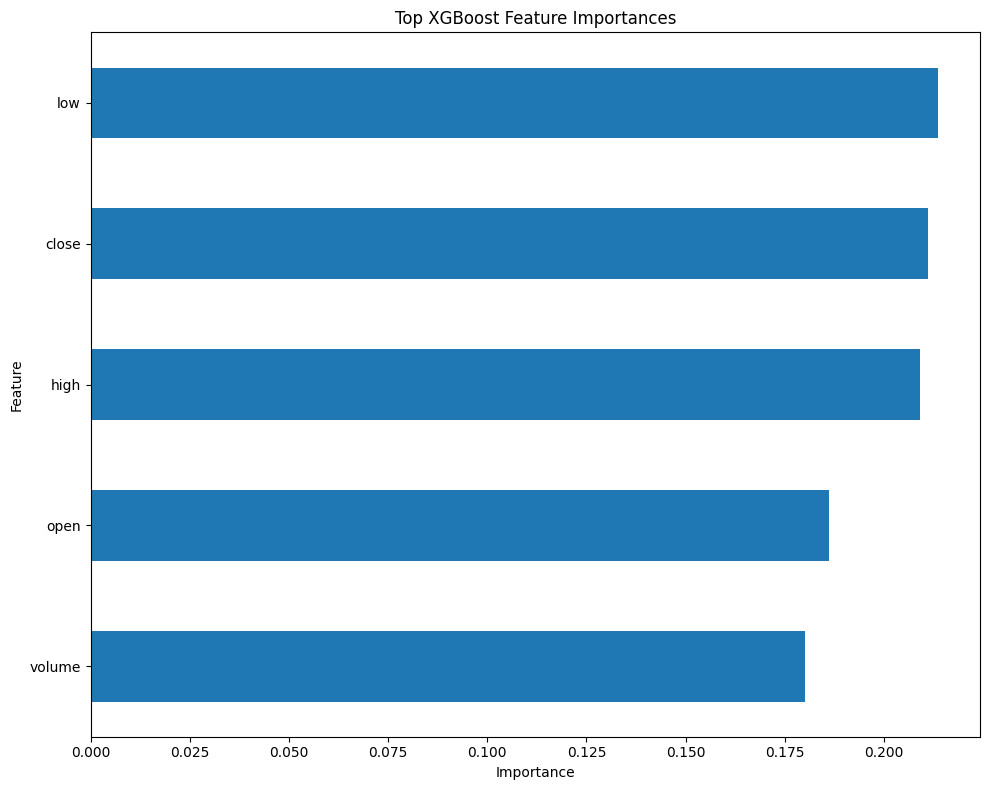

In [48]:
import matplotlib.pyplot as plt

top_n = 30

importance_df.head(top_n).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 8),
    legend=False
)

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

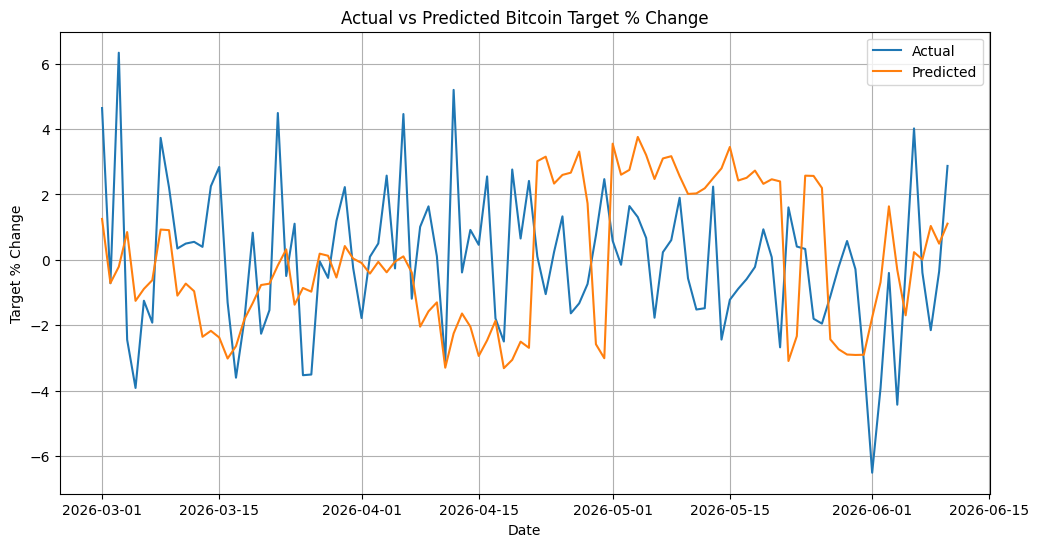

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(comparison.index, comparison["actual"], label="Actual")
plt.plot(comparison.index, comparison["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()